In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Concatenate, Embedding
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, LeakyReLU, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
import datetime
import io
import os
import json


2025-09-17 16:16:19.239916: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-17 16:16:19.330207: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-17 16:16:19.413713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758118579.499907  115912 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758118579.521768  115912 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758118579.677065  115912 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:

# --- 1. Load and Preprocess Data ---
(x_train, y_train), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5


In [ ]:

# --- 2. Define Model Constants and Hyperparameters ---
IMG_SHAPE = (32, 32, 3)
NUM_CLASSES = 10
LATENT_DIM = 128
EPOCHS = 3
BATCH_SIZE = 64
CRITIC_STEPS = 5
GP_WEIGHT = 10.0
LEARNING_RATE = 0.0001
BETA_1 = 0.5
BETA_2 = 0.9



In [ ]:
# --- 3. Build Critic and Generator Models ---
def build_critic():
    """Builds the Critic model (modified Discriminator for WGAN)."""
    img_input = Input(shape=IMG_SHAPE, name="critic_img_input")
    label_input = Input(shape=(1,), name="critic_label_input")
    label_embedding = Embedding(NUM_CLASSES, 50)(label_input)
    label_embedding = Dense(IMG_SHAPE[0] * IMG_SHAPE[1])(label_embedding)
    label_embedding = Reshape((IMG_SHAPE[0], IMG_SHAPE[1], 1))(label_embedding)
    concatenated_input = Concatenate()([img_input, label_embedding])
    x = Conv2D(64, kernel_size=4, strides=2, padding='same')(concatenated_input)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Conv2D(256, kernel_size=4, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Conv2D(512, kernel_size=4, strides=2, padding='same')(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = Flatten()(x)
    x = Dense(1)(x) # No sigmoid activation
    critic = Model([img_input, label_input], x, name="critic")
    return critic

def build_generator():
    """Builds the Generator model."""
    noise_input = Input(shape=(LATENT_DIM,), name="gen_noise_input")
    label_input = Input(shape=(1,), name="gen_label_input")
    label_embedding = Embedding(NUM_CLASSES, 50)(label_input)
    label_embedding = Dense(4 * 4)(label_embedding)
    label_embedding = Reshape((4, 4, 1))(label_embedding)
    noise = Dense(256 * 4 * 4, activation='relu')(noise_input)
    noise = Reshape((4, 4, 256))(noise)
    concatenated_input = Concatenate()([noise, label_embedding])
    x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu')(concatenated_input)
    x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu')(x)
    x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu')(x)
    x = Conv2D(3, kernel_size=5, padding='same', activation='tanh')(x)
    generator = Model([noise_input, label_input], x, name="generator")
    return generator



In [ ]:
# --- 4. Create the WGAN-GP Model Class (with advanced logging) ---
class WGAN(tf.keras.Model):
    def __init__(self, critic, generator, latent_dim, critic_extra_steps=5, gp_weight=10.0):
        super().__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.c_extra_steps = critic_extra_steps
        self.gp_weight = gp_weight
        

    def compile(self, c_optimizer, g_optimizer, file_writer):
        super().compile()
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer
        self.file_writer = file_writer
        self.c_loss_metric = tf.keras.metrics.Mean(name="c_loss")
        self.g_loss_metric = tf.keras.metrics.Mean(name="g_loss")
        self.w_dist_metric = tf.keras.metrics.Mean(name="w_dist")
        self.gp_metric = tf.keras.metrics.Mean(name="gp")

    @property
    def metrics(self):
        return [self.c_loss_metric, self.g_loss_metric, self.w_dist_metric, self.gp_metric]

    def gradient_penalty(self, batch_size, real_images, fake_images, labels):
        alpha = tf.random.normal([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff
        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            pred = self.critic([interpolated, labels], training=True)
        grads = gp_tape.gradient(pred, [interpolated])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    @tf.function
    def train_step(self, data):
        real_images, labels = data
        batch_size = tf.shape(real_images)[0]

        

        for i in range(self.c_extra_steps):
            random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
            with tf.GradientTape() as tape:
                fake_images = self.generator([random_latent_vectors, labels], training=True)
                real_output = self.critic([real_images, labels], training=True)
                fake_output = self.critic([fake_images, labels], training=True)
                w_dist = tf.reduce_mean(real_output) - tf.reduce_mean(fake_output)
                gp = self.gradient_penalty(batch_size, real_images, fake_images, labels)
                c_loss = -w_dist + gp * self.gp_weight
            c_gradient = tape.gradient(c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(zip(c_gradient, self.critic.trainable_variables))

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            generated_images = self.generator([random_latent_vectors, labels], training=True)
            gen_img_output = self.critic([generated_images, labels], training=True)
            g_loss = -tf.reduce_mean(gen_img_output)

        gen_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(gen_gradient, self.generator.trainable_variables))

        self.c_loss_metric.update_state(c_loss)
        self.g_loss_metric.update_state(g_loss)
        self.w_dist_metric.update_state(w_dist)
        self.gp_metric.update_state(gp)
        return {m.name: m.result() for m in self.metrics}

    def save_models(self, save_dir):
        """Save the generator, critic, and training hyperparameters."""
        os.makedirs(save_dir, exist_ok=True)

        generator_path = os.path.join(save_dir, "generator.keras")
        critic_path = os.path.join(save_dir, "critic.keras")
        self.generator.save(generator_path)
        self.critic.save(critic_path)
        print(f"Generator model saved to {generator_path}")
        print(f"Critic model saved to {critic_path}")

        hparams = {
            "latent_dim": self.latent_dim,
            "critic_extra_steps": self.c_extra_steps,
            "gp_weight": self.gp_weight
        }
        hparams_path = os.path.join(save_dir, "hparams.json")
        with open(hparams_path, "w") as f:
            json.dump(hparams, f)
        print(f"Hyperparameters saved to {hparams_path}")

# Add standalone loading function
def load_wgan_models(save_dir):
    """Load WGAN models from saved directory."""
    import json
    import os

    #Loading hyperparameters
    hparams_path = os.path.join(save_dir, 'hparams.json')
    with open(hparams_path, 'r') as f:
        hparams = json.load(f)

    #loading models
    generator_path = os.path.join(save_dir, 'generator.keras')
    critic_path = os.path.join(save_dir, 'critic.keras')

    generator = tf.keras.models.load_model(generator_path)
    critic = tf.keras.models.load_model(critic_path)

    print(f"Loaded generator from {generator_path}")
    print(f"Loaded critic from {critic_path}")

    #Create WGAN instance
    wgan = WGAN(
        critic=critic,
        generator=generator,
        latent_dim=hparams['latent_dim'],
        critic_extra_steps=hparams['critic_extra_steps'],
        gp_weight=hparams['gp_weight']
    )
    return wgan, hparams


In [6]:
# --- 5. Implement Image Sampler Callback with TensorBoard Logging ---
class ImageSampler(tf.keras.callbacks.Callback):
    def __init__(self, num_img=10, latent_dim=128, file_writer=None):
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.file_writer = file_writer

    def on_epoch_end(self, epoch, logs=None):
        if epoch > 0 and epoch % 5 == 0:
            noise = tf.random.normal(shape=(self.num_img, self.latent_dim))
            labels = tf.constant(np.arange(0, self.num_img).reshape(-1, 1))
            generated_images = self.model.generator.predict([noise, labels], verbose=0)
            generated_images = (generated_images + 1) / 2.0

            # Log the generated images to TensorBoard
            if self.file_writer:
                with self.file_writer.as_default():
                    tf.summary.image("Generated Images", generated_images, max_outputs=self.num_img, step=epoch)



In [ ]:
# --- 6. Train the Model with TensorBoard Callback ---
# Set up the log directory and file writer
log_dir = "logs/wgan/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
MODEL_SAVE_DIR = "models/wgan/"
TEST_SAVE_DIR = "models/wgan_test_verification/"
file_writer = tf.summary.create_file_writer(log_dir)

# Log hyperparameters as text
with file_writer.as_default():
    hparams = {
        "latent_dim": LATENT_DIM, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
        "critic_steps": CRITIC_STEPS, "gp_weight": GP_WEIGHT, "learning_rate": LEARNING_RATE,
        "beta_1": BETA_1, "beta_2": BETA_2
    }
    tf.summary.text("hyperparameters", tf.convert_to_tensor(
        [f'| {key} | {value} |' for key, value in hparams.items()]
    ), step=0)

critic = build_critic()
generator = build_generator()
wgan = WGAN(critic=critic, generator=generator, latent_dim=LATENT_DIM, critic_extra_steps=CRITIC_STEPS, gp_weight=GP_WEIGHT)

wgan.compile(
    c_optimizer=Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1, beta_2=BETA_2),
    g_optimizer=Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1, beta_2=BETA_2),
    file_writer=file_writer
)

# Set up the callbacks
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
sampler_callback = ImageSampler(latent_dim=LATENT_DIM, file_writer=file_writer)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE)

#Smoke test for checking the logging and other things
history = wgan.fit(train_dataset, epochs=EPOCHS, callbacks=[sampler_callback, tensorboard_callback])



2025-09-17 16:17:20.563102: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-09-17 16:17:21.364600: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


In [ ]:
#model saving on kaggle for local download
import shutil
import os

# Define the folder where the model will live
KAGGLE_MODEL_PATH = '/kaggle/working/wgan_final'

print("--- Saving Final Model for Local Download ---")
# This uses the save_models function you defined in Cell 5
wgan.save_models(KAGGLE_MODEL_PATH)

# Zip the folder so you can download it as one file from the Kaggle sidebar
shutil.make_archive("wgan_local_bundle", 'zip', KAGGLE_MODEL_PATH)

print("\n✅ DONE! Download 'wgan_local_bundle.zip' from the Output files on the right.")

In [1]:
# --- 7. Launch TensorBoard ---
# This cell is for your LOCAL notebook. It points to the directory where you downloaded the logs.
#%load_ext tensorboard
#%tensorboard --logdir /home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/kaggle_outputs/WGAN_GP_with_TensorBoard_Logging/logs/wgan

In [ ]:
# # Genearting synthetic images from the saved model

# def generate_synthetic_data(model_path, num_samples=5000, batch_size=64):
#     """Generate synthetic data from the saved WGAN model."""

#     #load the trained model
#     wgan, hparams = load_wgan_models(model_path)

#     synthetic_images = []
#     synthetic_labels = []
    
#     num_batches = (num_samples + batch_size - 1) // batch_size
    
#     for batch_idx in range(num_batches):
#         current_batch_size = min(batch_size, num_samples - batch_idx * batch_size)
        
#         #generate random noise and labels
#         noise = tf.random.normal(shape=(current_batch_size, hparams['latent_dim']))
#         labels = tf.random.uniform(shape=(current_batch_size, 1), minval=0, maxval=NUM_CLASSES, dtype=tf.int32)

#         #Generate images 
#         generated_images = wgan.generator([noise, labels], training=False)

#         synthetic_images.append(generated_images.numpy())
#         synthetic_labels.append(labels.numpy().flatten())

#         if (batch_idx + 1) % 10 == 0:
#             print(f"Generated batch {batch_idx + 1}/{num_batches}")

#     #concatenate all batches
#     synthetic_images = np.concatenate(synthetic_images, axis=0)
#     synthetic_labels = np.concatenate(synthetic_labels, axis=0)

#     print(f"Generated {synthetic_images.shape[0]} synthetic images.")
#     return synthetic_images, synthetic_labels

# # Example usage (uncomment when using a saved model):
# # model_path = "saved_models/wgan/20231014-123456/final_model"  # Update with the actual path
# # synthetic_images, synthetic_labels = generate_synthetic_data(model_path, num_samples=5000)

# # # Save the generated data
# # np.save('generated_synthetic_images.npy', synthetic_images)
# # np.save('generated_synthetic_labels.npy', synthetic_labels)
# # print("Synthetic data saved!")
    

SyntaxError: incomplete input (2128576609.py, line 4)

In [ ]:
# # loading and testing a saved WGAN model

# def test_loaded_model(model_path):
#     """Load and test a saved WGAN model."""

#     #Load the trained model
#     wgan, hparams = load_wgan_models(model_path)

#     #Generate a few test images 
#     noise = tf.random.normal(shape=(10, hparams['latent_dim']))
#     labels = tf.constant(np.arange(0, 10).reshape(-1, 1))

#     generated_images = wgan.generator([noise, labels], training=False)
#     generated_images = (generated_images + 1) / 2.0 #scale to [0, 1]

#     #Display the generated images
#     plt.figure(figsize=(15,2))
#     for i in range(10):
#         plt.subplot(1, 10, i + 1)
#         plt.imshow(generated_images[i])
#         plt.title(f"Class: {labels[i].numpy()[0]}")
#         plt.axis("off")
#     plt.tight_layout()
#     plt.show()

#     print("Model loaded and tested successfully")
#     return wgan

# # Example usage (uncomment when you have a saved model):
# # model_path = "saved_models/wgan/20231014-123456/final_model"
# # loaded_wgan = test_loaded_model(model_path)   


In [ ]:
# ## Loading all the datasets 

# SYNTHETIC_DATA_DIR = '/home/taz/Documents/Masters/DeepLearning/Deep-Learning/DataAugmentationConditionalGan/data/WassersteinLoss' 

# # Load the original CIFAR-10 data (training and testing sets)
# (x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = tf.keras.datasets.cifar10.load_data()

# # Debug: Check if directory exists
# print(f"Checking directory: {SYNTHETIC_DATA_DIR}")
# print(f"Directory exists: {os.path.exists(SYNTHETIC_DATA_DIR)}")
# if os.path.exists(SYNTHETIC_DATA_DIR):
#     print(f"Files in directory: {os.listdir(SYNTHETIC_DATA_DIR)}")

# # Load your generated synthetic data from the files you downloaded
# try:
#     synthetic_images = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_images.npy'))
#     synthetic_labels = np.load(os.path.join(SYNTHETIC_DATA_DIR, 'synthetic_labels.npy'))
#     print("--- Datasets Loaded Successfully ---")
# except FileNotFoundError:
#     print(f"--- ERROR: Could not find dataset files in '{SYNTHETIC_DATA_DIR}' ---")
#     print("Please make sure 'synthetic_images.npy' and 'synthetic_labels.npy' are in the correct folder.")
#     # Exit if files are not found
#     exit()

# print(f"Original training images shape: {x_train_orig.shape}")
# print(f"Synthetic training images shape: {synthetic_images.shape}")
# print(f"Test images shape: {x_test_orig.shape}")
# print("-" * 25)

In [ ]:
    # # Display some synthetic images with their labels
    # num_examples = 10
    # plt.figure(figsize=(15, 2))
    # for i in range(num_examples):
    #     plt.subplot(1, num_examples, i + 1)
    #     plt.imshow(synthetic_images[i])
    #     plt.title(f"Label: {synthetic_labels[i]}")
    #     plt.axis('off')
    # plt.tight_layout()
    # plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.036820340901613235..0.03029823675751686].
/tmp/ipykernel_159359/2804201193.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Raw\nLabel: {int(synthetic_labels[i])}")
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027968309819698334..0.027844969183206558].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03493374213576317..0.03211752325296402].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.028830967843532562..0.024884777143597603].
Clipping input data

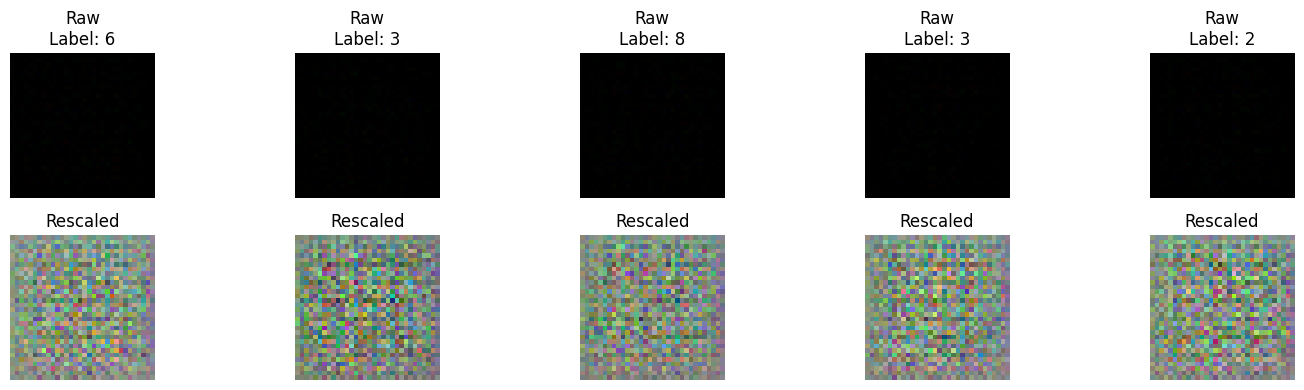

In [ ]:
# from skimage.exposure import rescale_intensity

# num_examples = 5
# indices = np.random.choice(len(synthetic_images), num_examples, replace=False)
# plt.figure(figsize=(15, 4))
# for idx, i in enumerate(indices):
#     # Raw image (as stored, typically in [-1, 1])
#     plt.subplot(2, num_examples, idx + 1)
#     plt.imshow(synthetic_images[i])
#     plt.title(f"Raw\nLabel: {int(synthetic_labels[i])}")
#     plt.axis('off')
    
#     # Rescaled image to [0, 1] for visualization
#     plt.subplot(2, num_examples, num_examples + idx + 1)
#     img = rescale_intensity(synthetic_images[i], in_range='image', out_range=(0, 1))
#     plt.imshow(img)
#     plt.title("Rescaled")
#     plt.axis('off')
# plt.tight_layout()
# plt.show()


In [ ]:
# ##Preprocessing the data

# print("\n--- Preprocessing Data ---")
# # Normalize original images from [0, 255] to [0, 1] for the classifier.
# x_train_orig = x_train_orig.astype('float32') / 255.0
# x_test_orig = x_test_orig.astype('float32') / 255.0

# # Rescale synthetic images from the GAN's [-1, 1] range to the classifier's [0, 1] range.
# synthetic_images = (synthetic_images + 1) / 2.0

# # One-hot encode the labels. This converts class vectors (integers) to a binary matrix,
# # which is required for the 'categorical_crossentropy' loss function.
# y_train_orig_cat = to_categorical(y_train_orig, 10)
# y_test_orig_cat = to_categorical(y_test_orig, 10)
# synthetic_labels_cat = to_categorical(synthetic_labels, 10)
# print("Data preprocessing complete.")
# print("-" * 25)


--- Preprocessing Data ---
Data preprocessing complete.
-------------------------


In [ ]:
# ## Builidng your own classifier model and trianing it 

# def build_classifier():
#     """Builds a standard CNN for CIFAR-10 classification."""
#     model = Sequential([
#         Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
#         Conv2D(32, (3, 3), activation='relu'),
#         MaxPooling2D((2, 2)),
#         Dropout(0.25),

#         Conv2D(64, (3, 3), activation='relu', padding='same'),
#         Conv2D(64, (3, 3), activation='relu'),
#         MaxPooling2D((2, 2)),
#         Dropout(0.25),

#         Flatten(),
#         Dense(512, activation='relu'),
#         Dropout(0.5),
#         Dense(10, activation='softmax') # Softmax for multi-class probability output
#     ])
    
#     model.compile(optimizer='adam',
#                   loss='categorical_crossentropy',
#                   metrics=['accuracy'])
#     return model

# print("\n--- Classifier Model Architecture ---")
# classifier_template = build_classifier()
# classifier_template.summary()
# print("-" * 25)


# # --- Phase 3 & 4: Step 4 - Run Experiments and Evaluate ---

# EPOCHS = 25
# BATCH_SIZE = 64
# results = {}



--- Classifier Model Architecture ---


/home/taz/Documents/Masters/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

-------------------------


In [ ]:
# # --- Experiment 1: Train on Original Data Only (Baseline) ---
# print("\n--- Starting Experiment 1: Original Data Only ---")
# classifier_orig = build_classifier()
# history_orig = classifier_orig.fit(x_train_orig, y_train_orig_cat,
#                                    epochs=EPOCHS,
#                                    batch_size=BATCH_SIZE,
#                                    validation_data=(x_test_orig, y_test_orig_cat),
#                                    verbose=1)
# # The final validation accuracy is the key result
# results['original_only'] = history_orig.history['val_accuracy'][-1]
# print("-" * 25)



--- Starting Experiment 1: Original Data Only ---
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 106ms/step - accuracy: 0.3335 - loss: 1.7854 - val_accuracy: 0.5746 - val_loss: 1.1893
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 99ms/step - accuracy: 0.5695 - loss: 1.2012 - val_accuracy: 0.6125 - val_loss: 1.0832
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 99ms/step - accuracy: 0.6416 - loss: 1.0218 - val_accuracy: 0.6853 - val_loss: 0.9038
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.6826 - loss: 0.9042 - val_accuracy: 0.7222 - val_loss: 0.7915
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 99ms/step - accuracy: 0.7107 - loss: 0.8198 - val_accuracy: 0.7375 - val_loss: 0.7583
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.7299 - loss: 0.7660 - val_accuracy: 0.7456 - val_loss: 0.7139
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.7471 - loss: 0.7214 - val_accuracy: 0.7594 - val_loss: 0.6866
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━

In [ ]:
# # --- Experiment 2: Train on Synthetic Data Only ---
# print("\n--- Starting Experiment 2: Synthetic Data Only ---")
# classifier_synth = build_classifier()
# history_synth = classifier_synth.fit(synthetic_images, synthetic_labels_cat,
#                                      epochs=EPOCHS,
#                                      batch_size=BATCH_SIZE,
#                                      validation_data=(x_test_orig, y_test_orig_cat),
#                                      verbose=1)
# results['synthetic_only'] = history_synth.history['val_accuracy'][-1]
# print("-" * 25)


--- Starting Experiment 2: Synthetic Data Only ---
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.0988 - loss: 2.3037 - val_accuracy: 0.0973 - val_loss: 2.3026
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.0991 - loss: 2.3027 - val_accuracy: 0.0999 - val_loss: 2.3026
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.0995 - loss: 2.3026 - val_accuracy: 0.0999 - val_loss: 2.3026
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.0982 - loss: 2.3027 - val_accuracy: 0.1020 - val_loss: 2.3026
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.1005 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.0998 - loss: 2.3027 - val_accuracy: 0.1077 - val_loss: 2.3026
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.1010 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/25
782/782 ━━━━━━━━━━━━

In [ ]:
# # --- Experiment 3: Train on Original + Synthetic Data ---
# print("\n--- Starting Experiment 3: Augmented Data ---")
# # Combine the original and synthetic datasets
# augmented_images = np.concatenate([x_train_orig, synthetic_images])
# augmented_labels = np.concatenate([y_train_orig_cat, synthetic_labels_cat])

# # It's crucial to shuffle the combined dataset to mix real and fake images during training
# shuffle_indices = np.random.permutation(len(augmented_images))
# augmented_images = augmented_images[shuffle_indices]
# augmented_labels = augmented_labels[shuffle_indices]

# classifier_aug = build_classifier()
# history_aug = classifier_aug.fit(augmented_images, augmented_labels,
#                                  epochs=EPOCHS,
#                                  batch_size=BATCH_SIZE,
#                                  validation_data=(x_test_orig, y_test_orig_cat),
#                                  verbose=1)
# results['augmented'] = history_aug.history['val_accuracy'][-1]
# print("-" * 25)



--- Starting Experiment 3: Augmented Data ---
Epoch 1/25


2025-07-27 21:10:55.078667: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1228800000 exceeds 10% of free system memory.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 104ms/step - accuracy: 0.2165 - loss: 2.0549 - val_accuracy: 0.5798 - val_loss: 1.1861
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 163s 104ms/step - accuracy: 0.3429 - loss: 1.7386 - val_accuracy: 0.6689 - val_loss: 0.9465
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 164s 105ms/step - accuracy: 0.3807 - loss: 1.6398 - val_accuracy: 0.7105 - val_loss: 0.8336
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 162s 104ms/step - accuracy: 0.3992 - loss: 1.5834 - val_accuracy: 0.7275 - val_loss: 0.7898
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.4101 - loss: 1.5526 - val_accuracy: 0.7451 - val_loss: 0.7443
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 105ms/step - accuracy: 0.4163 - loss: 1.5380 - val_accuracy: 0.7524 - val_loss: 0.7210
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.4228 - loss: 1.5079 - val_accuracy: 0.7543 - val_loss: 0.7297
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 167s 107ms/step - accuracy: 0.4

In [ ]:
# # --- Phase 4: Final Results Summary ---
# print("\n\n--- Final Classification Accuracy Results ---")
# print(f"Baseline (Original Data Only): {results.get('original_only', 0.0):.4f}")
# print(f"GAN-Generated Data Only:       {results.get('synthetic_only', 0.0):.4f}")
# print(f"Augmented (Original + GAN):    {results.get('augmented', 0.0):.4f}")
# print("-" * 40)




--- Final Classification Accuracy Results ---
Baseline (Original Data Only): 0.7952
GAN-Generated Data Only:       0.1011
Augmented (Original + GAN):    0.7880
----------------------------------------


In [ ]:
# # using pre-trained model to classify images with TensorBoard logging

# def build_finetune_classifier(input_shape=(32, 32, 3), num_classes=10):
#     """
#     Builds a classifier using a pre-trained MobileNetV2 base, ready for fine-tuning.
#     """
#     # Load the MobileNetV2 model pre-trained on ImageNet, without the top classification layer
#     base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
    
#     # Freeze the base model's layers to prevent them from being updated initially
#     base_model.trainable = False

#     # Create the new model architecture
#     inputs = Input(shape=input_shape)
    
#     # Upsample CIFAR-10's 32x32 images to 96x96 to better suit the pre-trained model
#     x = UpSampling2D(size=(3,3))(inputs)
    
#     # Pass data through the frozen base model
#     x = base_model(x, training=False)

#     # Add a new classification head
#     x = GlobalAveragePooling2D()(x)
#     x = Dropout(0.3)(x) # Use dropout for regularization
#     outputs = Dense(num_classes, activation='softmax')(x)

#     model = Model(inputs, outputs)

#     # Compile the model with a low learning rate, crucial for fine-tuning
#     model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
#                   loss='categorical_crossentropy',
#                   metrics=['accuracy'])
    
#     return model

#### Experiments with different Datasets


In [ ]:
# # Setting up the experiments 
# EPOCHS = 15
# BATCH_SIZE = 64
# results = {}
# # --- Experiment 1: Fine-tune on Original Data Only ---
# print("\n--- Starting Experiment 1: Original Data Only (Finetune) ---")
# classifier_orig = build_finetune_classifier()
# log_dir_orig = "logs/classifier/original_only_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback_orig = TensorBoard(log_dir=log_dir_orig, histogram_freq=1)
# print(f"TensorBoard logs will be saved in: {log_dir_orig}")

# history_orig = classifier_orig.fit(x_train_orig, y_train_orig_cat,
#                                    epochs=EPOCHS, batch_size=BATCH_SIZE,
#                                    validation_data=(x_test_orig, y_test_orig_cat),
#                                    callbacks=[tensorboard_callback_orig], verbose=1)
# results['original_finetune'] = history_orig.history['val_accuracy'][-1]


In [ ]:
# # Experiment 2: Fine-tune on Synthetic Data Only
# print("\n--- Starting Experiment 2: Synthetic Data Only (Finetune) ---")
# classifier_synth = build_finetune_classifier() # Build a fresh model instance
# log_dir_synth = "logs/classifier/synthetic_only_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback_synth = TensorBoard(log_dir=log_dir_synth, histogram_freq=1)
# print(f"TensorBoard logs will be saved in: {log_dir_synth}")

# history_synth = classifier_synth.fit(synthetic_images, synthetic_labels_cat,
#                                      epochs=EPOCHS, batch_size=BATCH_SIZE,
#                                      validation_data=(x_test_orig, y_test_orig_cat),
#                                      callbacks=[tensorboard_callback_synth], verbose=1)
# results['synthetic_finetune'] = history_synth.history['val_accuracy'][-1]



In [ ]:
# # --- Experiment with the Augemented Dataset

# print("\n--- Starting Experiment 3: Augmented Data (Finetune) ---")
# # Combine original and synthetic datasets
# augmented_images = np.concatenate([x_train_orig, synthetic_images])
# augmented_labels = np.concatenate([y_train_orig_cat, synthetic_labels_cat])
# # Shuffle the combined dataset
# shuffle_indices = np.random.permutation(len(augmented_images))
# augmented_images = augmented_images[shuffle_indices]
# augmented_labels = augmented_labels[shuffle_indices]

# classifier_aug = build_finetune_classifier() # Build a fresh model instance
# log_dir_aug = "logs/classifier/augmented_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback_aug = TensorBoard(log_dir=log_dir_aug, histogram_freq=1)
# print(f"TensorBoard logs will be saved in: {log_dir_aug}")

# history_aug = classifier_aug.fit(augmented_images, augmented_labels,
#                                  epochs=EPOCHS, batch_size=BATCH_SIZE,
#                                  validation_data=(x_test_orig, y_test_orig_cat),
#                                  callbacks=[tensorboard_callback_aug], verbose=1)
# results['augmented_finetune'] = history_aug.history['val_accuracy'][-1]


In [ ]:
# # --- Final Results Summary ---
# print("\n\n--- Final Classification Accuracy Results (Finetune) ---")
# print(f"Baseline (Original Data Only): {results.get('original_finetune', 0.0):.4f}")
# print(f"GAN-Generated Data Only:       {results.get('synthetic_finetune', 0.0):.4f}")
# print(f"Augmented (Original + GAN):    {results.get('augmented_finetune', 0.0):.4f}")
# print("-" * 50)